In [28]:
##import the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

In [29]:
##load dataset into variable titled df (eventually change to Afolabi's studentencoded .csv file)

df = pd.read_csv("./student_scaled.csv") 

In [30]:
df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,...,True,False,True,False,False,False,True,True,False,False
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,...,False,False,False,True,False,False,False,True,True,False
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,...,True,False,True,False,True,False,True,True,True,False
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,...,True,False,False,True,True,True,True,True,True,True
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,...,False,False,False,True,True,False,True,True,False,False


In [42]:
##creating features variable to be used to in our unsupervised learning model

features = [
    "studytime",
    "freetime",
    "goout", # going out w/ friends
    "Dalc", # workday alcohol consumption
    "Walc", # weekend alcohol consumption
    "health", 
    "absences"
]

X_features = df[features].copy()

X_features.head()

,studytime,freetime,goout,Dalc,Walc,health,absences
0,-0.042286,-0.236010,0.801479,-0.540699,-1.003789,-0.399289,0.036424
1,-0.042286,-0.236010,-0.097908,-0.540699,-1.003789,-0.399289,-0.213796
2,-0.042286,-0.236010,-0.997295,0.583385,0.551100,-0.399289,0.536865
3,1.150779,-1.238419,-0.997295,-0.540699,-1.003789,1.041070,-0.464016
4,-0.042286,-0.236010,-0.997295,-0.540699,-0.226345,1.041070,-0.213796


### Why did you choose these features?
These features were chosen because we wanted to explore and predict the g3 grades based on the students lifestyle and not on their past grades. We essentially explored students with similar backgrounds to see if that factored into having similar grades as well. Including the G1 and G2 grades to the features would make our model's prediction highly based on the past grades rather than the lifestyle cluster we would like to achieve.

In [32]:
k_range = range(2,11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    cluster_labels = kmeans.fit_predict(X_features)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_features, cluster_labels))


### How did you decide how many clusters to use?
We decided to test two techniques to choose how many clusters would be optimal for our model.

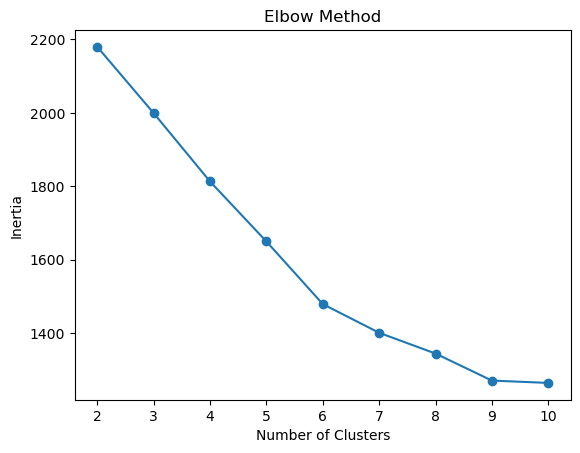

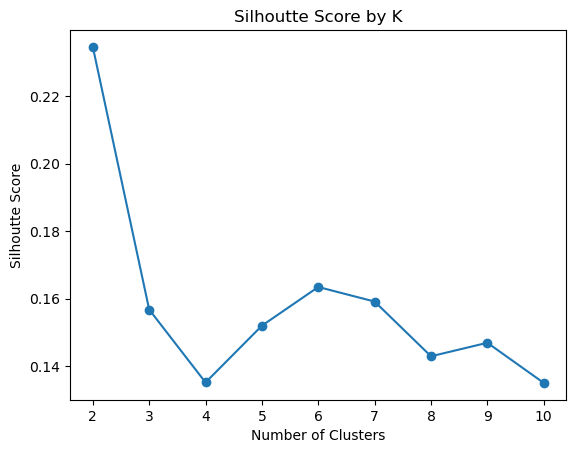

In [33]:
# Plotting Inertia vs Silhoutte scores
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhoutte Score')
plt.title('Silhoutte Score by K')
plt.show()

### Choosing Cluster Amount
We checked to see which K would be the best for our clusters. Two methods were applied to see where they agree. Based on both graphs combined k=2 is the best amount of clusters. The silhoutte score shows that any amount of clusters above 2 is bound to result in ineffective clusters because they have a relaytively low score. Although we agreed on k=2, we noticed that the score is still pretty low overall. We assumed our features probably made hard to turn these clusters into distinct clusters with a low amount of overlapping. 

In [34]:
# Fit predict with K=2
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_features)

In [35]:
# Seperate Clusters
cols = ["studytime",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences"
    ]

df.groupby('cluster')[cols].mean()

,studytime,freetime,goout,Dalc,Walc,health,absences
cluster,,,,,,,
0,0.186817,-0.181531,-0.332531,-0.430734,-0.505211,-0.093996,-0.105458
1,-0.433290,0.421031,0.771248,0.999013,1.171749,0.218007,0.244591


### Cluster Separation Observation
Noticing some very interesting patterns here.

In [36]:
df.groupby('cluster')['G3'].mean()


cluster
0    10.641304
1     9.890756
Name: G3, dtype: float64

### G3 Results Based on Clusters
The G3 Averages are aligning with the clusters produced

In [37]:
df.groupby('cluster')['G3'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,276.0,10.641304,4.883921,0.0,9.0,11.0,14.0,20.0
1,119.0,9.890756,3.754748,0.0,8.0,10.0,12.0,18.0


<function matplotlib.pyplot.show(close=None, block=None)>

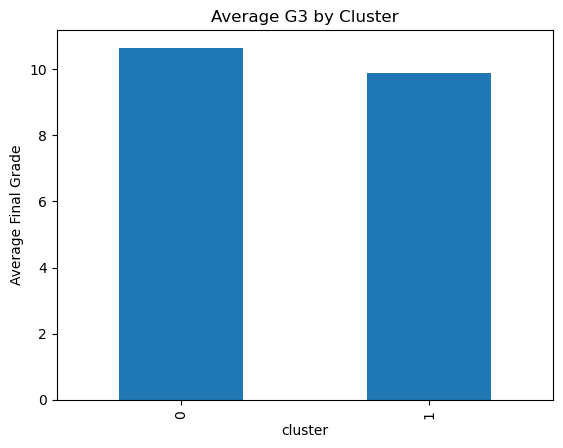

In [38]:
df.groupby('cluster')['G3'].mean().plot(kind='bar')
plt.ylabel('Average Final Grade')
plt.title('Average G3 by Cluster')
plt.show

# Model Summary
Initially we decided not to include G1 and G2 in our features because we did not want our model to solely rely on those grades to make a prediction because it would be a simple calculation.

We decided to use features that cluster the students based on lifestyle. We thought it would be more interesting to explore the effects of lifestyle on the students grades.

